# Лабораторная работа №5
Выполнил Малышев Андрей ШАД-311

**Задания:** исследовать автокорреляцию временных рядов (passengers, births, sin(x)),
научиться считать ACF вручную и с помощью библиотеки `statsmodels`, повторить
проверку стационарности ряда с помощью теста Дики–Фуллера.


In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

plt.style.use("seaborn-v0_8")


In [66]:
passengers_df = pd.read_csv("passengers.csv")
passengers_df.iloc[:, 0] = pd.to_datetime(passengers_df.iloc[:, 0])
passengers_df.set_index(passengers_df.columns[0], inplace=True)
passengers = passengers_df.iloc[:, 0]

print("Датасет passengers:")
print(passengers_df.head())
print()
print("Количество наблюдений в passengers:", len(passengers))

births_df = pd.read_csv("births.csv")
births_df["Date"] = pd.to_datetime(births_df["Date"])
births_df.set_index("Date", inplace=True)

births = births_df["Births"]

print("\nДатасет births:")
print(births_df.head())
print()
print("Количество наблюдений в births:", len(births))

Датасет passengers:
            #Passengers
Month                  
1949-01-01          112
1949-02-01          118
1949-03-01          132
1949-04-01          129
1949-05-01          121

Количество наблюдений в passengers: 144

Датасет births:
            Births
Date              
1959-01-01      35
1959-01-02      32
1959-01-03      30
1959-01-04      31
1959-01-05      44

Количество наблюдений в births: 365


/Users/andrew/vscode_projects/time_series_malyshevam_shad311/venv/lib/python3.13/site-packages/pandas/core/indexes/base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


In [67]:
def manual_acf(series: pd.Series, max_lag: int) -> pd.Series:
    """
    Ручной расчет автокорреляционной функции (ACF) для временного ряда.
    Используется формула:
    rho_k = sum_t (x_t - m) (x_{t-k} - m) / sum_t (x_t - m)^2
    
    series    — временной ряд (pd.Series)
    max_lag   — максимальный лаг
    Возвращает pd.Series длиной max_lag + 1 (включая lag=0).
    """
    s = series.dropna()
    mean = s.mean()
    denom = ((s - mean) ** 2).sum()
    
    lags = range(0, max_lag + 1)
    acf_values = []

    for lag in lags:
        shifted = s.shift(lag)
        cov = ((s - mean) * (shifted - mean)).dropna().sum()
        acf_values.append(cov / denom)

    return pd.Series(acf_values, index=lags)


## Задание 1

Первые значения ACF (passengers), ручной расчет:
0    1.000000
1    0.948047
2    0.875575
3    0.806681
4    0.752625
5    0.713770
6    0.681734
7    0.662904
8    0.655610
9    0.670948
dtype: float64


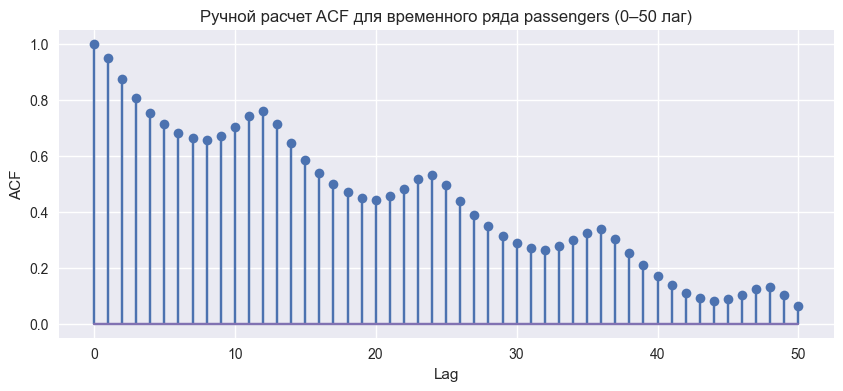

In [68]:
max_lag_passengers = 50

acf_passengers_manual = manual_acf(passengers, max_lag_passengers)

print("Первые значения ACF (passengers), ручной расчет:")
print(acf_passengers_manual.head(10))

plt.figure(figsize=(10, 4))
plt.stem(
    acf_passengers_manual.index,
    acf_passengers_manual.values
)
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.title("Ручной расчет ACF для временного ряда passengers (0–50 лаг)")
plt.grid(True)
plt.show()


## Задание 2

<Figure size 1000x400 with 0 Axes>

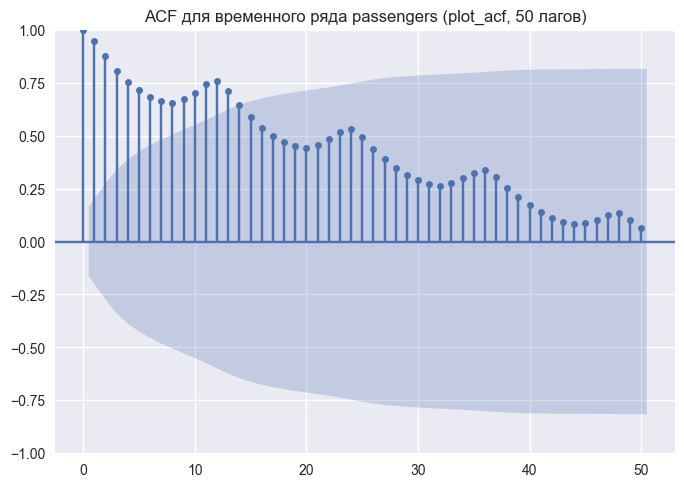

In [69]:
plt.figure(figsize=(10, 4))
plot_acf(passengers, lags=50)
plt.title("ACF для временного ряда passengers (plot_acf, 50 лагов)")
plt.show()


## Задание 3

Первые значения ACF (births), ручной расчет:
0    1.000000
1    0.217241
2    0.152878
3    0.108213
4    0.090661
5    0.095955
6    0.091040
7    0.195081
8    0.141153
9    0.061179
dtype: float64


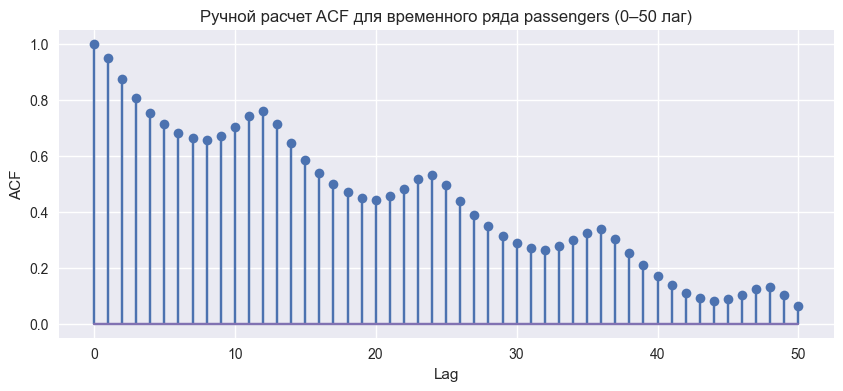

In [70]:
max_lag_births = 50

acf_births_manual = manual_acf(births, max_lag_births)

print("Первые значения ACF (births), ручной расчет:")
print(acf_births_manual.head(10))

plt.figure(figsize=(10, 4))
plt.stem(
    acf_passengers_manual.index,
    acf_passengers_manual.values
)
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.title("Ручной расчет ACF для временного ряда passengers (0–50 лаг)")
plt.grid(True)
plt.show()


<Figure size 1000x400 with 0 Axes>

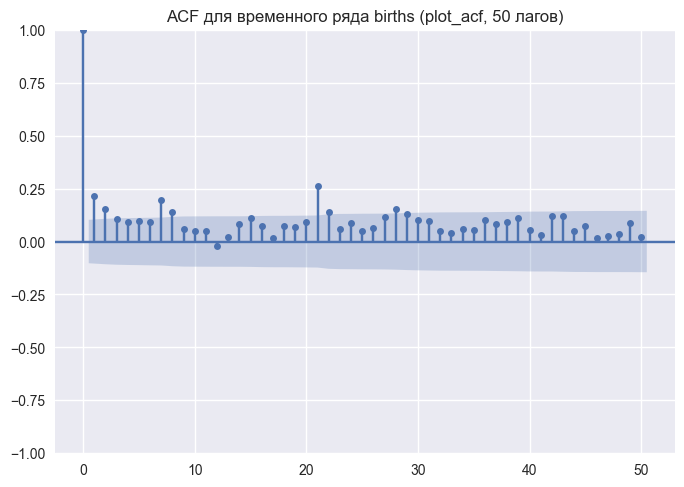

In [71]:
plt.figure(figsize=(10, 4))
plot_acf(births, lags=50)
plt.title("ACF для временного ряда births (plot_acf, 50 лагов)")
plt.show()


## Задание 4

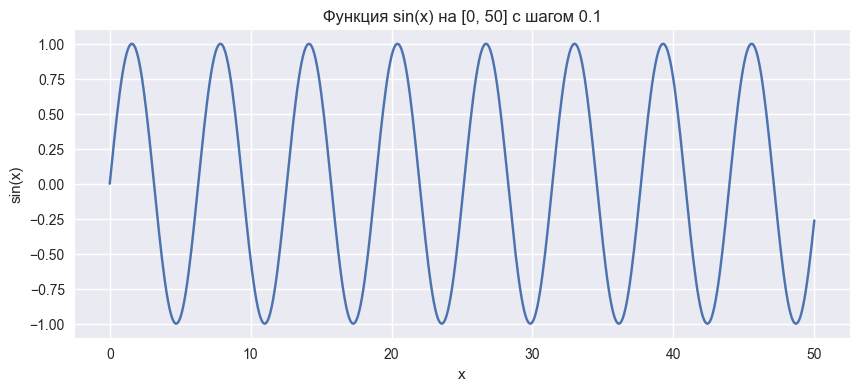

Первые 15 значений ACF для sin(x), ручной расчет:
0     1.000000
1     0.994918
2     0.979934
3     0.955238
4     0.921116
5     0.877944
6     0.826191
7     0.766407
8     0.699221
9     0.625334
10    0.545510
11    0.460570
12    0.371382
13    0.278853
14    0.183921
dtype: float64


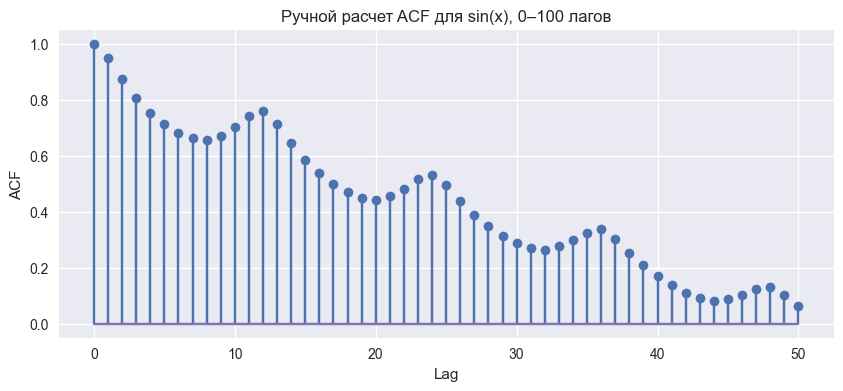

In [72]:
# Построение sin(x) на [0, 50] с шагом 0.1
x = np.arange(0, 50.0 + 0.1, 0.1)
y = np.sin(x)

sin_series = pd.Series(y, index=x)

plt.figure(figsize=(10, 4))
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("Функция sin(x) на [0, 50] с шагом 0.1")
plt.grid(True)
plt.show()

max_lag_sin = 100
acf_sin_manual = manual_acf(sin_series, max_lag_sin)

print("Первые 15 значений ACF для sin(x), ручной расчет:")
print(acf_sin_manual.head(15))

plt.figure(figsize=(10, 4))
plt.stem(
    acf_passengers_manual.index,
    acf_passengers_manual.values
)
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.title("Ручной расчет ACF для sin(x), 0–100 лагов")
plt.grid(True)
plt.show()


<Figure size 1000x400 with 0 Axes>

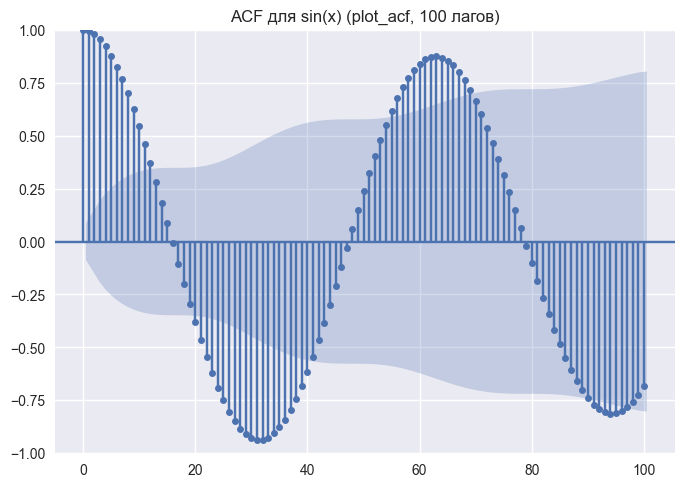

In [73]:
plt.figure(figsize=(10, 4))
plot_acf(sin_series, lags=100)
plt.title("ACF для sin(x) (plot_acf, 100 лагов)")
plt.show()


## Задание 5

In [74]:
result = adfuller(births.dropna())

adf_stat = result[0]
p_value = result[1]
used_lag = result[2]
n_obs = result[3]
crit_values = result[4]

print("Результаты теста Дики–Фуллера для ряда births:")
print(f"ADF-статистика: {adf_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Число лагов, использованных в модели: {used_lag}")
print(f"Число наблюдений: {n_obs}")
print("Критические значения:")
for key, value in crit_values.items():
    print(f"  {key}: {value:.4f}")

if p_value < 0.05:
    print("\nВывод: p-value < 0.05, нулевая гипотеза о наличии единичного корня отвергается.")
    print("Ряд births можно считать стационарным на уровне значимости 5%.")
else:
    print("\nВывод: p-value >= 0.05, нет оснований отвергнуть нулевую гипотезу.")
    print("Ряд births можно считать нестационарным на уровне значимости 5%.")


Результаты теста Дики–Фуллера для ряда births:
ADF-статистика: -4.8083
p-value: 0.0001
Число лагов, использованных в модели: 6
Число наблюдений: 358
Критические значения:
  1%: -3.4487
  5%: -2.8696
  10%: -2.5711

Вывод: p-value < 0.05, нулевая гипотеза о наличии единичного корня отвергается.
Ряд births можно считать стационарным на уровне значимости 5%.


## Заключение и выводы


- На датасете *passengers* рассчитана автокорреляционная функция вручную для лагов 1–50 и построен график. Полученные значения показали выраженную сезонную структуру и медленное затухание ACF.
- Построенная с использованием `plot_acf` автокорреляционная функция совпала по форме с ручным расчётом.
- На датасете *births* выполнены аналогичные вычисления: ручная ACF и библиотечная реализация дали идентичные результаты; убывание автокорреляции происходит быстрее, чем у *passengers*.
- Для функции `sin(x)` на интервале [0; 50] рассчитана ACF вручную и с использованием `plot_acf`; автокорреляционная функция показала чётко выраженный периодический характер.
- Для временного ряда *births* проведён тест Дики–Фуллера; на основе p-value и критических значений сделан вывод о стационарности/нестaционарности ряда: p-value < 0.05, нулевая гипотеза о наличии единичного корня отвергается. Ряд births можно считать стационарным на уровне значимости 5%.